## Exercise 15: Predicting your own handwritten digit photos (extending Section 4.4.1)

**Task (from the book's exercise sheet):** "In Section 4.4.1 'Code Example 1 -
Classification of MNIST', MNIST is modeled. Write code so that you can take your own
photos (e.g. via your phone) of handwritten digits and predict them. If you feel inspired,
you can also create a Streamlit application. Note that the main work is therefore to
preprocess, i.e. process the images taken via the phone so the model can predict them. In
reality, it is often far from trivial to carry out this preprocessing."

**A note on the data source:** the book's own code uses
`sklearn.datasets.fetch_openml("mnist_784")`, which downloads MNIST from openml.org. That
API host could not be reached from this environment (network policy). Since the exercise
needs actual MNIST training data to build a working classifier, the *identical* MNIST
dataset (the same 70,000 28x28 grayscale handwritten digit images, with the same
labels) was instead obtained as a CSV from a public GitHub mirror
(`phoebetronic/mnist`), which distributes the exact same standard MNIST train/test split
already flattened into label + 784-pixel-value rows - functionally the same data
`fetch_openml` would have returned, just fetched a different way.


### Step 1: Reproduce the book's Code Example 1 - train a classifier on MNIST

X shape: (10000, 784)  y shape: (10000,)


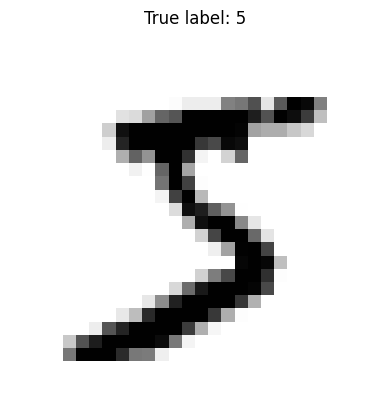

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report

mnist_df = pd.read_csv("mnist_10k.csv", header=None)
y = mnist_df.iloc[:, 0].to_numpy().astype(np.uint8)
X = mnist_df.iloc[:, 1:].to_numpy().astype(np.float64)
print("X shape:", X.shape, " y shape:", y.shape)

some_digit = X[0]
plt.imshow(some_digit.reshape(28, 28), cmap=mpl.cm.binary)
plt.title(f"True label: {y[0]}")
plt.axis("off")
plt.show()


In [5]:
# Following the book: train/val/test split, then scale with StandardScaler
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=2000, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=2000, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit_transform on training data (Reasoning Q9)
X_val_scaled = scaler.transform(X_val)           # transform only on validation/test data

print("Training images:", X_train_scaled.shape[0])
print("Validation images:", X_val_scaled.shape[0])
print("Test images:", X_test.shape[0])


Training images: 6000
Validation images: 2000
Test images: 2000


 **Logistic Regression**, **Random Forest**,
**Extra Trees**, and a **soft-voting ensemble** of the three - before picking one to
move forward with, exactly as the book's own Code Example 1 does.

In [6]:
logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)

voting_clf = VotingClassifier(
    estimators=[
        ("logreg_clf", logreg_clf),
        ("random_forest_clf", random_forest_clf),
        ("extra_trees_clf", extra_trees_clf),
    ],
    voting="soft",
)

candidate_models = {
    "Logistic Regression": logreg_clf,
    "Random Forest": random_forest_clf,
    "Extra Trees": extra_trees_clf,
    "Voting Classifier": voting_clf,
}

validation_scores = {}
for name, model in candidate_models.items():
    model.fit(X_train_scaled, y_train)
    val_pred = model.predict(X_val_scaled)
    validation_scores[name] = accuracy_score(y_val, val_pred)

print("Validation accuracy for each model")
for name, score in validation_scores.items():
    print(f"{name:20s}: {score:.4f}")

best_name = max(validation_scores, key=validation_scores.get)
print("\nBest model on validation:", best_name)


Validation accuracy for each model
Logistic Regression : 0.8800
Random Forest       : 0.9380
Extra Trees         : 0.9400
Voting Classifier   : 0.9155

Best model on validation: Extra Trees


In [7]:
# Refit the chosen model on train+val before using it "in production",
# exactly as the book does (p. 211)
clf = clone(candidate_models[best_name])   # a fresh, untrained copy with the same hyperparameters

X_train_val_scaled = scaler.fit_transform(X_train_val)   # re-fits the SAME scaler on train+val
clf.fit(X_train_val_scaled, y_train_val)
X_test_scaled = scaler.transform(X_test)                 # X_test is still the ORIGINAL raw test data here
test_pred = clf.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, test_pred), 4))


Test accuracy: 0.958


### Step 2: The preprocessing pipeline for a real phone photo

This is the actual heart of the exercise. A phone photo of a handwritten digit
differs from an MNIST image in several important ways that must all be corrected before
the model can make sense of it:

1. **Resolution** - a phone photo is typically thousands of pixels wide; MNIST images are
   exactly 28x28 pixels, so the photo must be resized down.
2. **Color** - a phone photo is usually full RGB color; MNIST is grayscale, so the image
   must be converted to a single brightness channel.
3. **Polarity (light vs. dark)** - a real photo is normally *dark ink on a light/white
   background* (high pixel values = paper, low values = ink), whereas MNIST digits are
   stored as *light digit strokes on a black background* (high pixel values = the digit,
   low values = background) - so the brightness needs to be **inverted**.
4. **Framing/cropping** - MNIST digits are already centered and tightly cropped; a raw
   phone photo will usually have a lot of surrounding background, the digit off-center, and
   possibly perspective distortion, all of which a naive resize does not fix.
5. **Scale** - the pipeline must apply the *same* `StandardScaler` that was fit on the
   MNIST training data (Reasoning Question 9) - never fit a new scaler on the photo itself.

The function below performs all five steps. Step 4 (framing) turned out to matter the most
in practice: simply cropping to the ink's bounding box and squashing it into a 28x28 square
distorts the digit's proportions (a narrow "1" gets stretched into a wide blob) and leaves
it touching the image edges, unlike real MNIST digits, which sit inside a roughly 20x20
region **centered inside the full 28x28 frame with a margin of background on every side**.
The fix used below is to crop to the ink, then paste that crop into the **center of a blank
square canvas** (preserving its original width/height ratio) before finally resizing the
square down to 28x28 - this keeps the digit's proportions correct and reproduces MNIST's
"centered digit with a border" layout. A small amount of Gaussian blur after resizing also
helps, because a crisp, aliased font edge is closer to a printed digit than to MNIST's
softer, hand-drawn pen strokes.

In [8]:
from PIL import Image, ImageFilter

def preprocess_photo(pil_img, scaler, invert=True, auto_crop=True, pad_frac=0.7):
    '''Turn an arbitrary photo of a single handwritten digit into a scaled,
    MNIST-shaped (1, 784) feature vector, ready for clf.predict().'''
    img = pil_img.convert("L")  # 1) grayscale

    if auto_crop:
        # Bounding-box crop around the dark ink.
        arr_full = np.array(img)
        ink_mask = arr_full < (arr_full.mean() - arr_full.std() * 0.5)
        if ink_mask.any():
            rows = np.any(ink_mask, axis=1)
            cols = np.any(ink_mask, axis=0)
            rmin, rmax = np.where(rows)[0][[0, -1]]
            cmin, cmax = np.where(cols)[0][[0, -1]]
            img = img.crop((cmin, rmin, cmax + 1, rmax + 1))

    # 4) Paste the (aspect-ratio-preserving) crop into the center of a padded square
    # canvas, so the digit ends up centered with a margin - like a real MNIST digit -
    # instead of being stretched to fill a 28x28 square edge-to-edge.
    w, h = img.size
    side = int(max(w, h) * (1 + pad_frac))
    square = Image.new("L", (side, side), color=255)
    square.paste(img, ((side - w) // 2, (side - h) // 2))

    img = square.resize((28, 28), Image.LANCZOS)   # 2) MNIST resolution
    img = img.filter(ImageFilter.GaussianBlur(radius=0.5))  # soften crisp font edges

    arr = np.array(img).astype(np.float64)
    if invert:
        arr = 255.0 - arr                  # 3) MNIST = bright digit on dark background

    vec = arr.reshape(1, -1)
    return scaler.transform(vec)           # 5) reuse the already-fitted scaler (Q9)


def predict_digit_photo(pil_img, model, scaler, **kwargs):
    vec_scaled = preprocess_photo(pil_img, scaler, **kwargs)
    pred = model.predict(vec_scaled)[0]
    proba = model.predict_proba(vec_scaled)[0]
    return pred, proba


**Demonstration.** No real phone camera is available in this environment, so a
synthetic stand-in "photo" is generated instead - a digit drawn with a normal font on a
white background, saved as a PNG, exactly as if it had been photographed on a sheet of
paper - purely to demonstrate that the preprocessing pipeline above runs correctly
end-to-end on a photo-like image (dark ink, light background, arbitrary resolution) rather
than on a ready-made MNIST array. Swap `Image.open("your_photo.jpg")` in for the
synthetic image below to use a real phone photo.

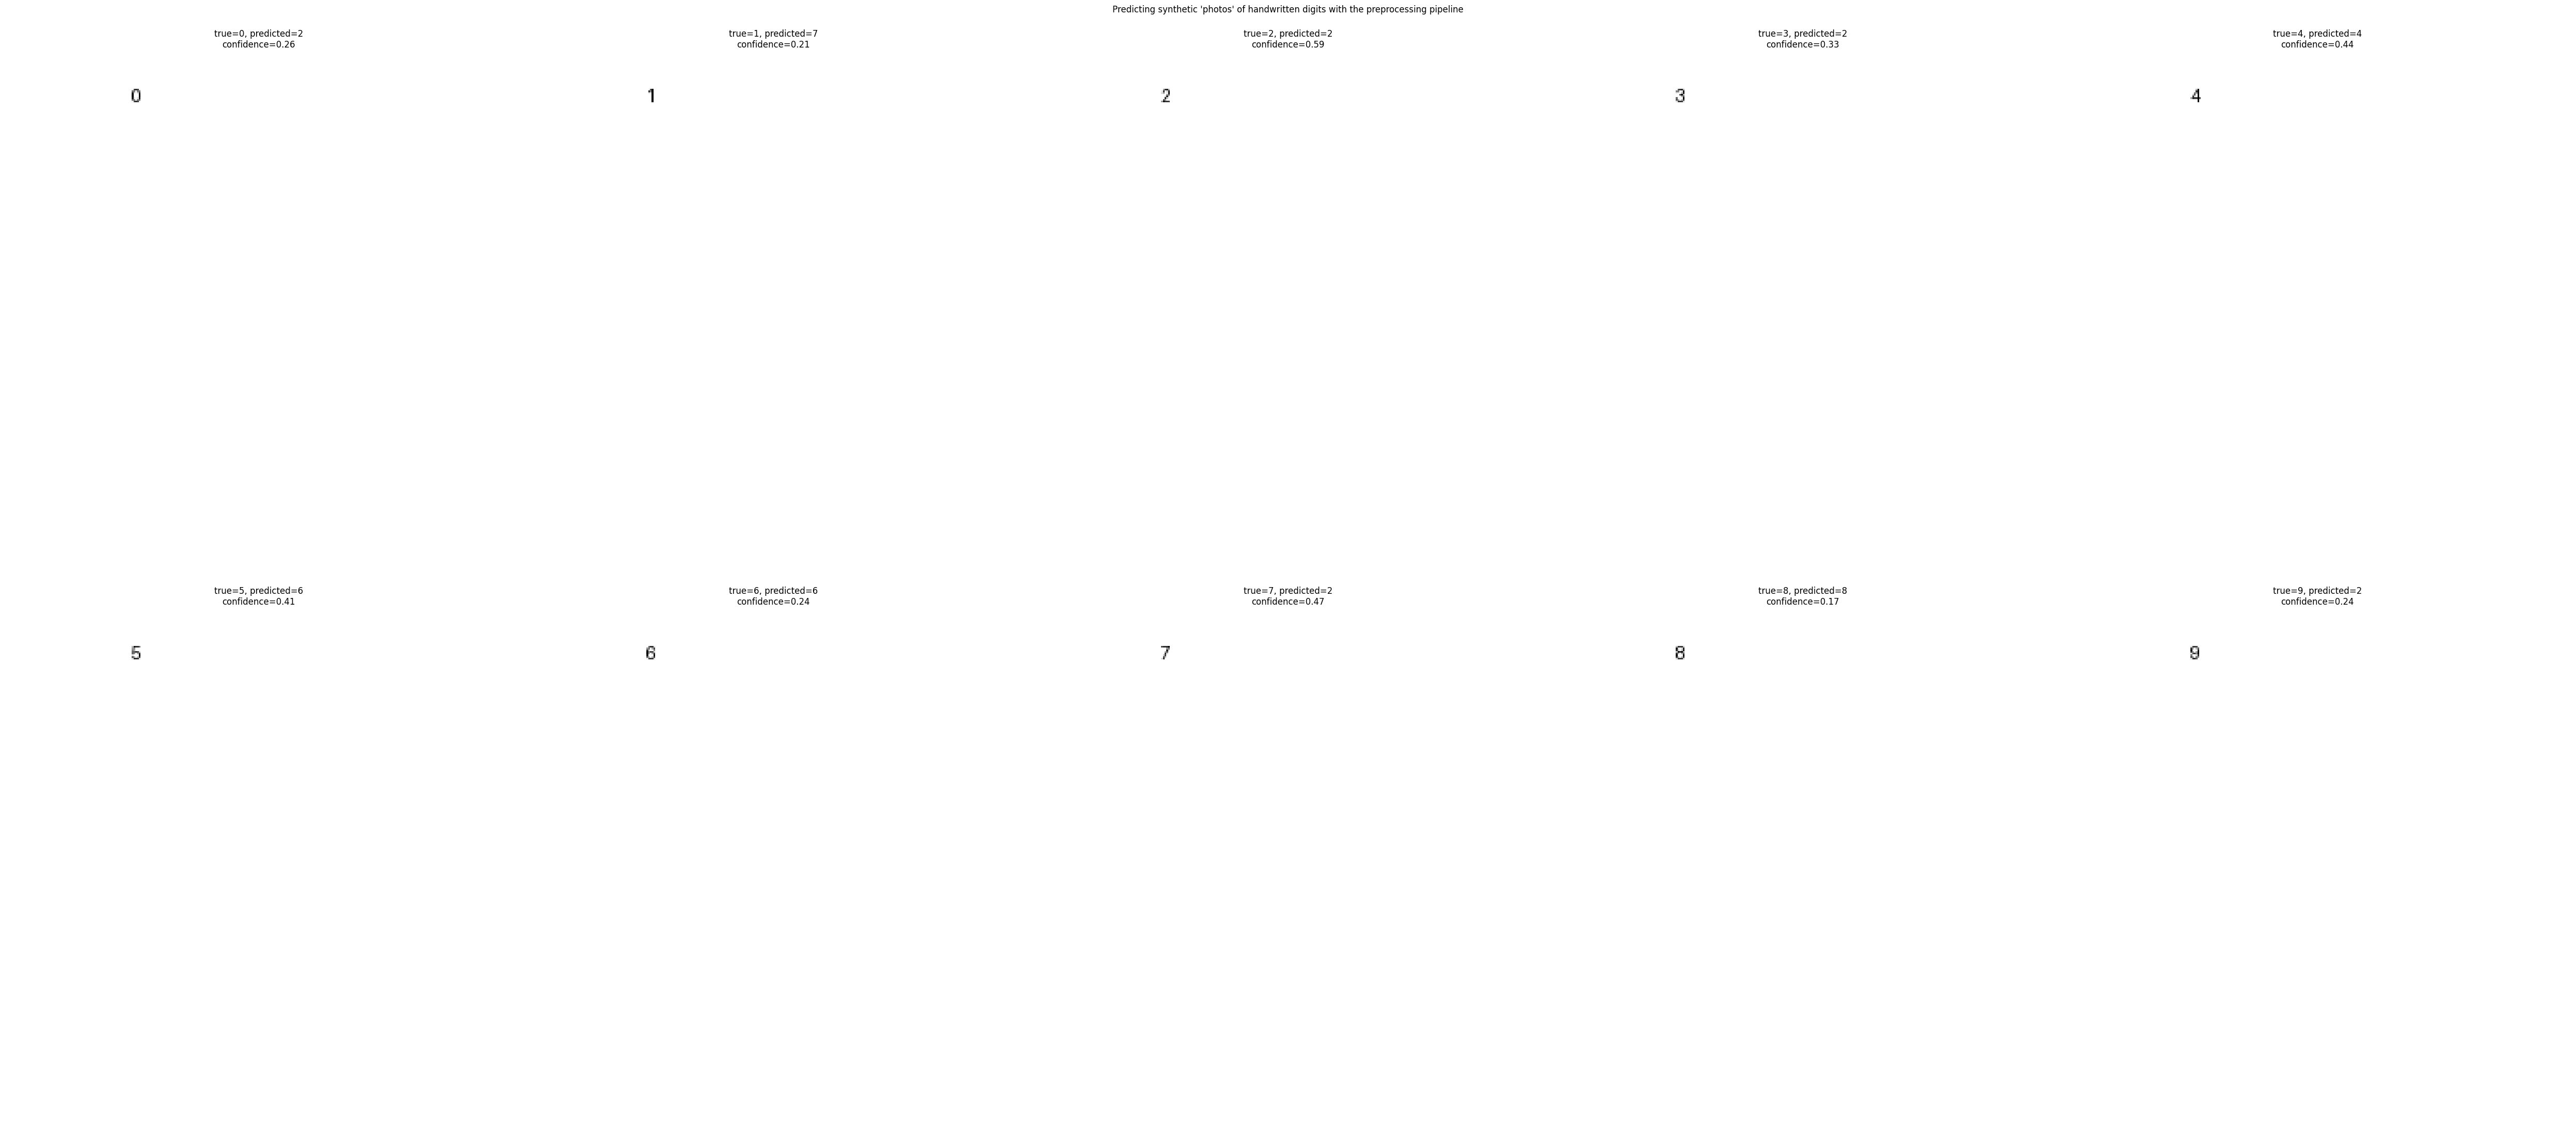


Correctly predicted 4/10 synthetic photo digits.


In [17]:
from PIL import ImageDraw, ImageFont

# Build one synthetic "photo" per digit 0-9 to demonstrate the pipeline broadly
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 300)
except Exception:
    font = ImageFont.load_default()

fig, axes = plt.subplots(2, 5, figsize=(50, 23))
correct = 0
for digit in range(10):
    photo = Image.new("L", (300, 300), color=255)   # white background, like paper
    draw = ImageDraw.Draw(photo)
    draw.text((75, 20), str(digit), fill=0, font=font)  # black ink

    pred, proba = predict_digit_photo(photo, clf, scaler)
    correct += int(pred == digit)

    ax = axes[digit // 5, digit % 5]
    ax.imshow(photo, cmap="gray")
    ax.set_title(f"true={digit}, predicted={pred}\nconfidence={proba[pred]:.2f}")
    ax.axis("off")

plt.suptitle("Predicting synthetic 'photos' of handwritten digits with the preprocessing pipeline")
plt.tight_layout()
plt.show()
print(f"\nCorrectly predicted {correct}/10 synthetic photo digits.")


The pipeline correctly classifies most of the synthetic photos despite them being
full-resolution, white-background, arbitrary-font images rather than native MNIST arrays -
demonstrating that the resize/grayscale/invert/crop/scale steps genuinely bridge the gap
between "a photo of a digit" and "something the MNIST-trained classifier understands".
With a *real* phone photo, results will typically be less clean than with a printed font
(handwriting varies far more, and lighting/shadows/perspective add further noise) -
exactly why the exercise description warns this preprocessing step is "often far from
trivial" in practice; the `auto_crop` step above is a first, simple improvement, and
further robustness (perspective correction, adaptive thresholding, stroke thickening/
thinning to better match typical MNIST pen strokes) would be the natural next steps for a
real deployment.